# Marketing CSVs vs Actual Paid DAU

Compare the marketing team's two weekly Paid-DAU forecast CSVs against actual paid DAU pulled from `mozdata.fenix.active_users`.

**Actuals definition** (mirrors STMO 118452 cohort): a client is "paid" if its `new_profile_clients` row has `paid_vs_organic_gclid='Paid'` AND `install_source='com.android.vending'`. Once paid, always paid. Daily paid DAU = count of `fenix.active_users` rows with `is_dau=true` whose `client_id` is in that paid cohort.

**CSVs under comparison:**
- `paid_dau_weekly_forecast.20260519.csv` — v1: `baseline_dau` (pre-2026 cohort, constant 523,070) + `post_2026_dau` (growing) → `total_paid_dau`.
- `paid_dau_weekly_forecast.v2_model.20260520.csv` — v2: `paid_dau_gt_1yr` + `paid_dau_lte_12mo` → `total_paid_dau`.

Both span 2026-01-05 → 2026-12-28 (51 Monday rows).

**Views produced:**
1. Weekly-summed actuals overlaid on the CSVs (apples-to-apples if CSV values are weekly sums).
2. Weekly-mean actuals overlaid on the CSVs (apples-to-apples if CSV values are average daily DAU within a week).
3. Daily actuals + weekly CSV markers.
4. Residual table for the in-sample weeks (2026-01-05 through ~2026-05-18).


In [49]:
# setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.cloud import bigquery

pd.set_option("display.float_format", "{:,.0f}".format)

PROJECT = "moz-fx-data-bq-data-science"
CACHE_PATH = Path("data/paid_dau_actuals_mobile_ytd.parquet")  # Android paid cohort + iOS all-organic
FORCE_REQUERY = False  # set True to bypass parquet cache and re-hit BigQuery

CSV_DIR = Path("/Users/brendanwells/work/mozaic-daily/.claude/worktrees/marketing-real-data/marketing_real_data_model/data")
CSV_V1 = CSV_DIR / "paid_dau_weekly_forecast.20260519.csv"
CSV_V2 = CSV_DIR / "paid_dau_weekly_forecast.v2_model.20260520.csv"

bq = bigquery.Client(project=PROJECT)
print("BigQuery project:", PROJECT)
print("CSV v1 exists:", CSV_V1.exists(), "| CSV v2 exists:", CSV_V2.exists())
print("Actuals cache:", CACHE_PATH, "(exists:", CACHE_PATH.exists(), ")")


BigQuery project: moz-fx-data-bq-data-science
CSV v1 exists: True | CSV v2 exists: True
Actuals cache: data/paid_dau_actuals_mobile_ytd.parquet (exists: True )


In [50]:
# query-actuals
# Pull daily mobile DAU YTD (2026-01-01 onward) from BigQuery.
# Paid cohort = Fenix-Android clients with paid_vs_organic_gclid='Paid' AND
#               install_source='com.android.vending' (STMO 118452 definition).
# iOS contributes only to organic + total — Firefox iOS lacks a usable paid-attribution
# signal in new_profile_clients (paid_vs_organic_gclid is NULL on iOS; adjust_network
# returns ~22 paid out of 3.5M April clients).
#
# Costs ~$2-3 per run (full scans on fenix.active_users + firefox_ios.active_users
# + fenix.new_profile_clients).

ACTUALS_SQL = """
WITH paid_clients_android AS (
  SELECT DISTINCT client_id
  FROM `mozdata.fenix.new_profile_clients`
  WHERE first_seen_date <= CURRENT_DATE() - 1
    AND paid_vs_organic_gclid = 'Paid'
    AND install_source = 'com.android.vending'
),
android_daily AS (
  SELECT
    au.submission_date AS date,
    IF(pc.client_id IS NOT NULL, 'Paid', 'Organic') AS acquisition_type,
    IF(countries.name = 'Iran, Islamic Republic of' OR au.locale LIKE 'fa%', 1, 0) AS is_iran
  FROM `mozdata.fenix.active_users` AS au
  LEFT JOIN paid_clients_android AS pc ON au.client_id = pc.client_id
  LEFT JOIN `mozdata.static.country_codes_v1` AS countries ON au.country = countries.code
  WHERE au.submission_date >= DATE('2026-01-01')
    AND au.is_dau
),
ios_daily AS (
  SELECT
    au.submission_date AS date,
    'Organic' AS acquisition_type,  -- iOS lacks usable paid attribution; treat all as organic
    IF(countries.name = 'Iran, Islamic Republic of' OR au.locale LIKE 'fa%', 1, 0) AS is_iran
  FROM `mozdata.firefox_ios.active_users` AS au
  LEFT JOIN `mozdata.static.country_codes_v1` AS countries ON au.country = countries.code
  WHERE au.submission_date >= DATE('2026-01-01')
    AND au.is_dau
),
combined AS (
  SELECT * FROM android_daily
  UNION ALL
  SELECT * FROM ios_daily
)
SELECT
  date,
  COUNTIF(acquisition_type = 'Paid') AS paid_dau,
  COUNTIF(acquisition_type = 'Organic') AS organic_dau,
  COUNT(*) AS total_dau,
  COUNTIF(acquisition_type = 'Paid' AND is_iran = 0) AS paid_dau_ex_iran,
  COUNTIF(acquisition_type = 'Organic' AND is_iran = 0) AS organic_dau_ex_iran,
  COUNTIF(is_iran = 0) AS total_dau_ex_iran
FROM combined
GROUP BY date
ORDER BY date
"""

if CACHE_PATH.exists() and not FORCE_REQUERY:
    actuals = pd.read_parquet(CACHE_PATH)
    actuals["date"] = pd.to_datetime(actuals["date"])
    print(f"Loaded {len(actuals)} rows from cache {CACHE_PATH}")
else:
    print("Querying BigQuery (this scans Android + iOS active_users; ~30-60s)...")
    job = bq.query(ACTUALS_SQL)
    actuals = job.result().to_dataframe()
    actuals["date"] = pd.to_datetime(actuals["date"])
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    actuals.to_parquet(CACHE_PATH, index=False)
    print(f"Queried + cached {len(actuals)} rows -> {CACHE_PATH}")
    print(f"  bytes_billed: {job.total_bytes_billed / 1e9:.1f} GB")

print(f"Span: {actuals['date'].min().date()} -> {actuals['date'].max().date()} ({len(actuals)} days)")
print(actuals.head(3))
print(actuals.tail(3))


Loaded 140 rows from cache data/paid_dau_actuals_mobile_ytd.parquet
Span: 2026-01-01 -> 2026-05-20 (140 days)
        date  paid_dau  organic_dau  total_dau  paid_dau_ex_iran  \
0 2026-01-01    673474     13622285   14295759            668408   
1 2026-01-02    723977     14142786   14866763            719106   
2 2026-01-03    724377     14014787   14739164            718932   

   organic_dau_ex_iran  total_dau_ex_iran  
0             13067125           13735533  
1             13617187           14336293  
2             13476946           14195878  
          date  paid_dau  organic_dau  total_dau  paid_dau_ex_iran  \
137 2026-05-18   1242392     14501918   15744310           1241541   
138 2026-05-19   1262507     14561951   15824458           1261656   
139 2026-05-20   1264730     14621353   15886083           1263702   

     organic_dau_ex_iran  total_dau_ex_iran  
137             14439823           15681364  
138             14498789           15760445  
139             145415

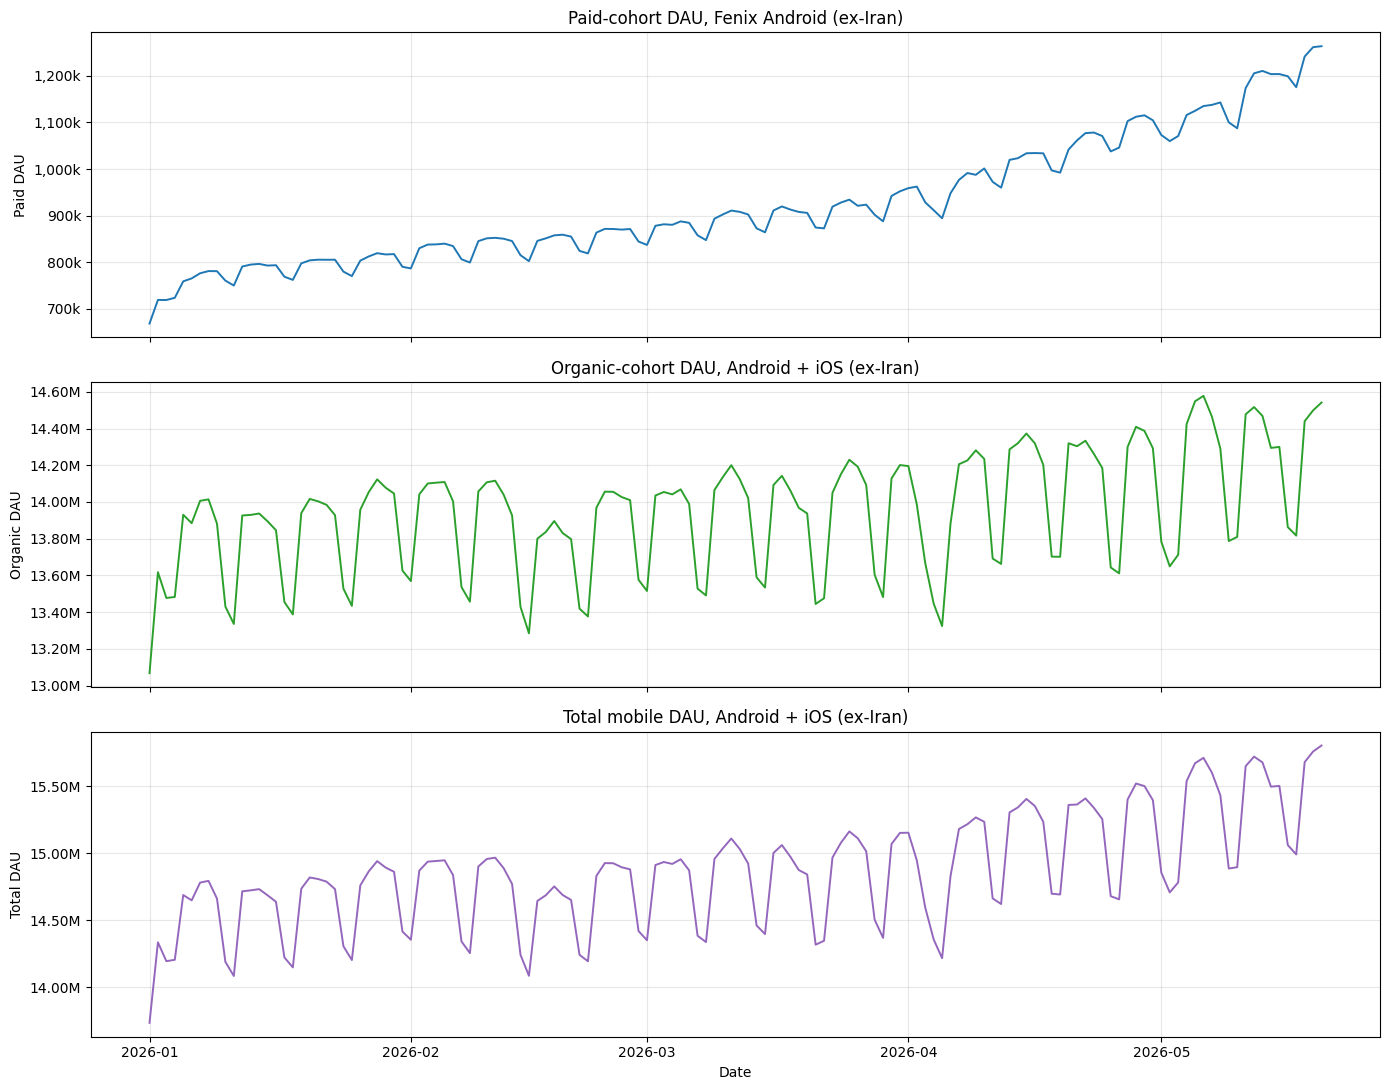

Paid (ex-Iran)    range:       668,408  ->      1,263,702
Organic (ex-Iran) range:    13,067,125  ->     14,577,938
Total (ex-Iran)   range:    13,735,533  ->     15,805,260


In [51]:
# plot-actuals-ex-iran
# Daily mobile DAU (ex-Iran): paid cohort (Android), organic (Android+iOS), total (Android+iOS).
fig, (ax_paid, ax_organic, ax_total) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

ax_paid.plot(actuals["date"], actuals["paid_dau_ex_iran"], linewidth=1.4, color="tab:blue")
ax_paid.set_title("Paid-cohort DAU, Fenix Android (ex-Iran)")
ax_paid.set_ylabel("Paid DAU")
ax_paid.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:,.0f}k"))
ax_paid.grid(True, alpha=0.3)

ax_organic.plot(actuals["date"], actuals["organic_dau_ex_iran"], linewidth=1.4, color="tab:green")
ax_organic.set_title("Organic-cohort DAU, Android + iOS (ex-Iran)")
ax_organic.set_ylabel("Organic DAU")
ax_organic.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.2f}M"))
ax_organic.grid(True, alpha=0.3)

ax_total.plot(actuals["date"], actuals["total_dau_ex_iran"], linewidth=1.4, color="tab:purple")
ax_total.set_title("Total mobile DAU, Android + iOS (ex-Iran)")
ax_total.set_xlabel("Date")
ax_total.set_ylabel("Total DAU")
ax_total.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.2f}M"))
ax_total.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Paid (ex-Iran)    range:", f"{actuals['paid_dau_ex_iran'].min():>13,.0f}  ->  {actuals['paid_dau_ex_iran'].max():>13,.0f}")
print("Organic (ex-Iran) range:", f"{actuals['organic_dau_ex_iran'].min():>13,.0f}  ->  {actuals['organic_dau_ex_iran'].max():>13,.0f}")
print("Total (ex-Iran)   range:", f"{actuals['total_dau_ex_iran'].min():>13,.0f}  ->  {actuals['total_dau_ex_iran'].max():>13,.0f}")


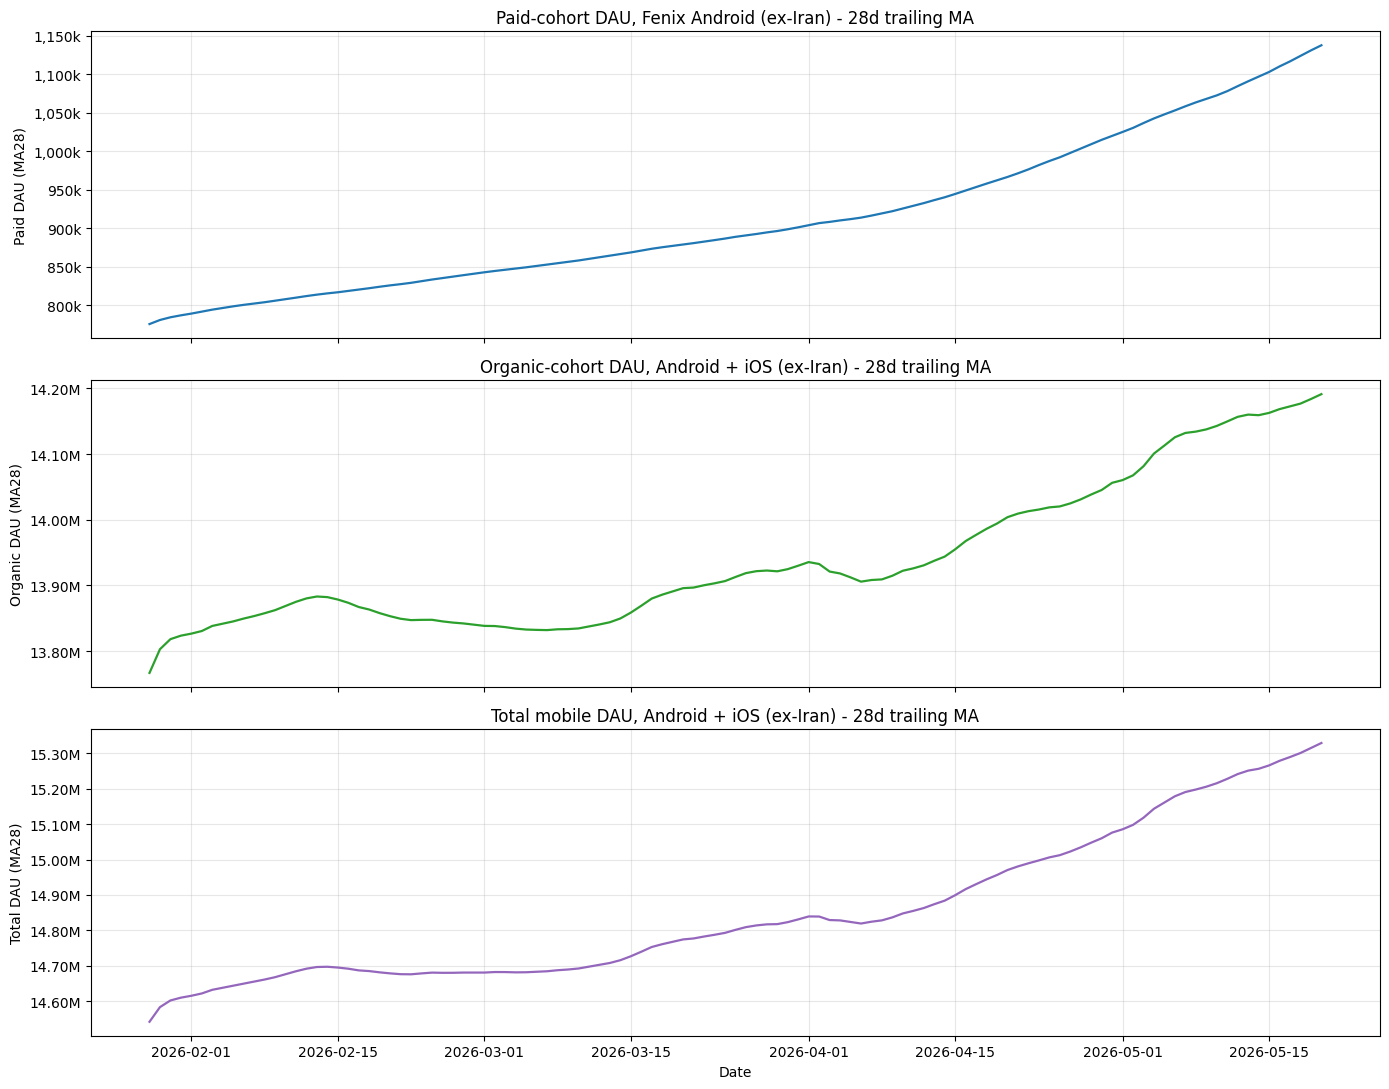

In [52]:
# plot-actuals-ex-iran-ma28
# Same three series (ex-Iran) as 28-day trailing means. Needs >=28 days of data;
# the first 27 days produce NaN and are skipped by matplotlib.
ma28 = actuals.set_index("date")[["paid_dau_ex_iran", "organic_dau_ex_iran", "total_dau_ex_iran"]].rolling(28).mean()

fig, (ax_paid, ax_organic, ax_total) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

ax_paid.plot(ma28.index, ma28["paid_dau_ex_iran"], linewidth=1.6, color="tab:blue")
ax_paid.set_title("Paid-cohort DAU, Fenix Android (ex-Iran) - 28d trailing MA")
ax_paid.set_ylabel("Paid DAU (MA28)")
ax_paid.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:,.0f}k"))
ax_paid.grid(True, alpha=0.3)

ax_organic.plot(ma28.index, ma28["organic_dau_ex_iran"], linewidth=1.6, color="tab:green")
ax_organic.set_title("Organic-cohort DAU, Android + iOS (ex-Iran) - 28d trailing MA")
ax_organic.set_ylabel("Organic DAU (MA28)")
ax_organic.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.2f}M"))
ax_organic.grid(True, alpha=0.3)

ax_total.plot(ma28.index, ma28["total_dau_ex_iran"], linewidth=1.6, color="tab:purple")
ax_total.set_title("Total mobile DAU, Android + iOS (ex-Iran) - 28d trailing MA")
ax_total.set_xlabel("Date")
ax_total.set_ylabel("Total DAU (MA28)")
ax_total.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.2f}M"))
ax_total.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [53]:
# load-csvs
def _parse_csv(path):
    df = pd.read_csv(path, thousands=",")
    df["week"] = pd.to_datetime(df["week"]).dt.date
    return df

csv_v1 = _parse_csv(CSV_V1)
csv_v2 = _parse_csv(CSV_V2)

print("v1 columns:", list(csv_v1.columns))
print("v2 columns:", list(csv_v2.columns))
print()
print("v1 head:"); print(csv_v1.head(3))
print()
print("v2 head:"); print(csv_v2.head(3))


v1 columns: ['week', 'baseline_dau', 'post_2026_dau', 'total_paid_dau']
v2 columns: ['week', 'paid_dau_gt_1yr', 'paid_dau_lte_12mo', 'total_paid_dau']

v1 head:
         week  baseline_dau  post_2026_dau  total_paid_dau
0  2026-01-05        523070          92908          615978
1  2026-01-12        523070         139680          662750
2  2026-01-19        523070         172863          695933

v2 head:
         week  paid_dau_gt_1yr  paid_dau_lte_12mo  total_paid_dau
0  2026-01-05           150109             694655          844764
1  2026-01-12           150668             710848          861517
2  2026-01-19           155426             718768          874194


In [54]:
# weekly-agg
# Aggregate daily actuals into Monday-anchored weeks (Mon–Sun blocks).
# Match the CSV week-label convention (the date IS the Monday).
daily = actuals.set_index("date").sort_index()
daily["week_start"] = (daily.index - pd.to_timedelta(daily.index.weekday, unit="D")).date

weekly = (
    daily.groupby("week_start")
    .agg(
        days_in_week=("paid_dau", "size"),
        paid_dau_sum=("paid_dau", "sum"),
        paid_dau_mean=("paid_dau", "mean"),
        paid_dau_ex_iran_sum=("paid_dau_ex_iran", "sum"),
        paid_dau_ex_iran_mean=("paid_dau_ex_iran", "mean"),
        total_dau_sum=("total_dau", "sum"),
        total_dau_mean=("total_dau", "mean"),
    )
    .reset_index()
    .rename(columns={"week_start": "week"})
)
# Only keep complete weeks (7 days) for clean comparison, but flag incomplete tail.
print(f"weekly rows: {len(weekly)}; complete (7d): {(weekly['days_in_week']==7).sum()}; partial: {(weekly['days_in_week']<7).sum()}")
print()
print(weekly.tail(8))


weekly rows: 21; complete (7d): 19; partial: 2

          week  days_in_week  paid_dau_sum  paid_dau_mean  \
13  2026-03-30             7       6551487        935,927   
14  2026-04-06             7       6838937        976,991   
15  2026-04-13             7       7136073      1,019,439   
16  2026-04-20             7       7415776      1,059,397   
17  2026-04-27             7       7641894      1,091,699   
18  2026-05-04             7       7848697      1,121,242   
19  2026-05-11             7       8377759      1,196,823   
20  2026-05-18             3       3769629      1,256,543   

    paid_dau_ex_iran_sum  paid_dau_ex_iran_mean  total_dau_sum  total_dau_mean  
13               6550670                935,810      103574383      14,796,340  
14               6837877                976,840      105118946      15,016,992  
15               7134453              1,019,208      106174576      15,167,797  
16               7413762              1,059,109      106229431      15,175,633

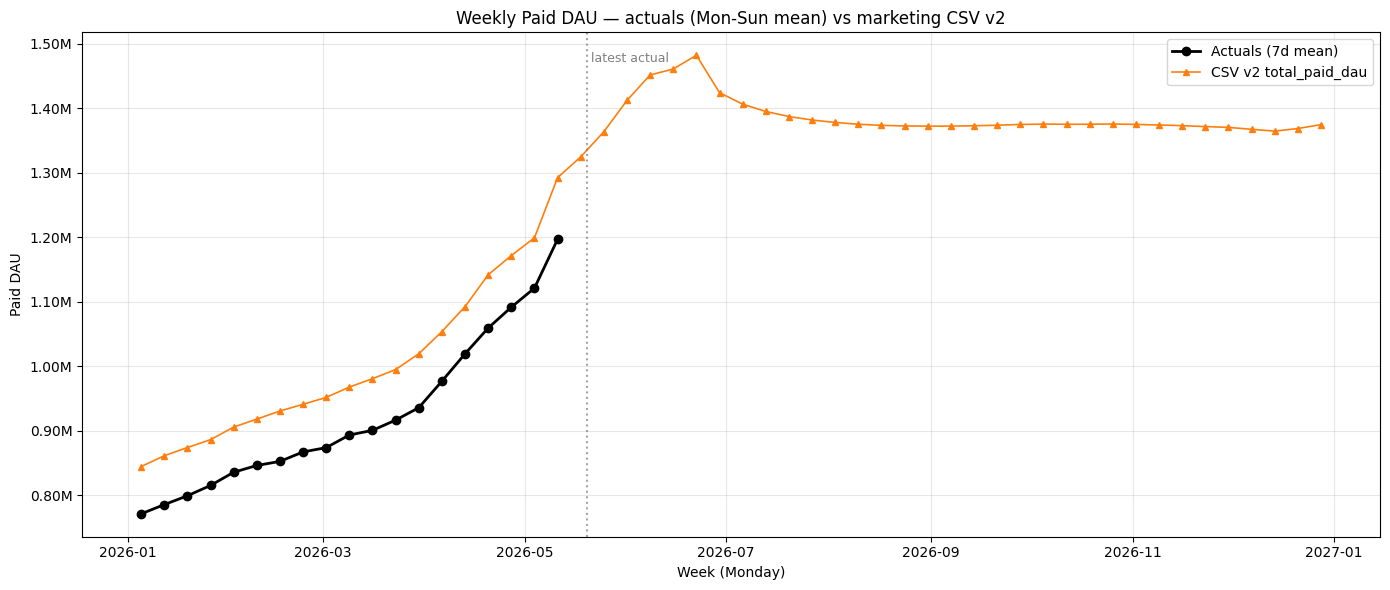

In [55]:
# plot-weekly-mean
# Weekly view: 7-day mean of daily paid DAU overlaid on the CSV v2 weekly value.
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(complete["week"], complete["paid_dau_mean"], marker="o", linewidth=2, label="Actuals (7d mean)", color="black", zorder=5)

# ax.plot(csv_v1["week"], csv_v1["total_paid_dau"], marker="s", markersize=4, linewidth=1.2, label="CSV v1 total_paid_dau", color="tab:blue")
ax.plot(csv_v2["week"], csv_v2["total_paid_dau"], marker="^", markersize=4, linewidth=1.2, label="CSV v2 total_paid_dau", color="tab:orange")

ax.set_title("Weekly Paid DAU — actuals (Mon-Sun mean) vs marketing CSV v2")
ax.set_xlabel("Week (Monday)")
ax.set_ylabel("Paid DAU")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.axvline(pd.Timestamp(actuals["date"].max().date()), color="grey", linestyle=":", alpha=0.7)
ax.text(pd.Timestamp(actuals["date"].max().date()), ax.get_ylim()[1]*0.98, " latest actual ", va="top", ha="left", fontsize=9, color="grey")
plt.tight_layout()
plt.show()


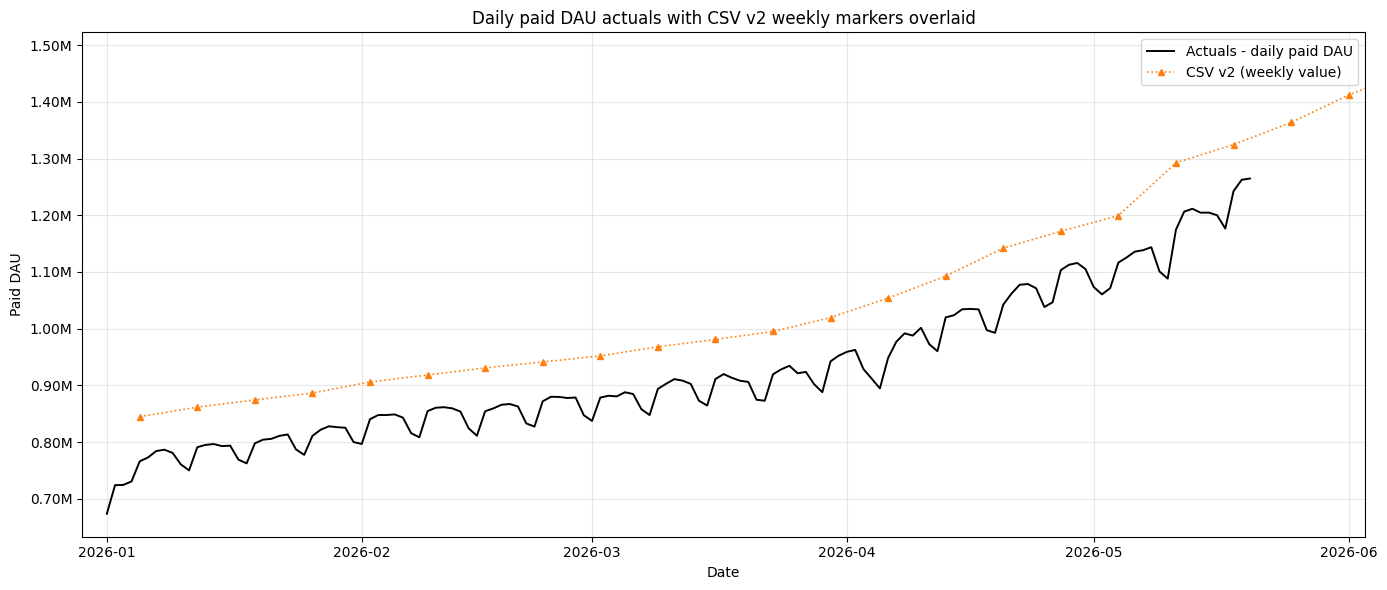

In [56]:
# plot-daily-overlay
# Daily paid DAU actuals overlaid on CSV v2 weekly markers.
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(actuals["date"], actuals["paid_dau"], linewidth=1.4, label="Actuals - daily paid DAU", color="black", zorder=4)

# ax.plot(pd.to_datetime(csv_v1["week"]), csv_v1["total_paid_dau"], marker="s", markersize=5, linestyle=":", linewidth=1.2, label="CSV v1 (weekly value)", color="tab:blue")
ax.plot(pd.to_datetime(csv_v2["week"]), csv_v2["total_paid_dau"], marker="^", markersize=5, linestyle=":", linewidth=1.2, label="CSV v2 (weekly value)", color="tab:orange")

ax.set_title("Daily paid DAU actuals with CSV v2 weekly markers overlaid")
ax.set_xlabel("Date")
ax.set_ylabel("Paid DAU")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.set_xlim(pd.Timestamp("2025-12-29"), pd.Timestamp(actuals["date"].max().date()) + pd.Timedelta(days=14))
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


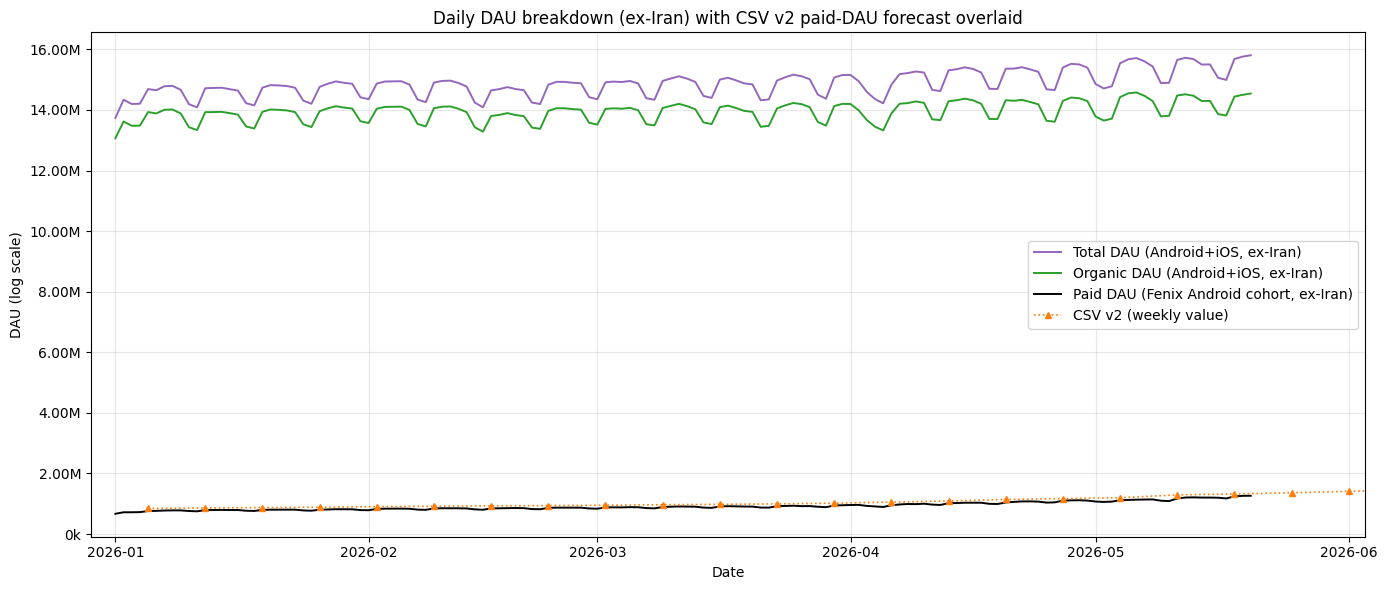

In [ ]:
# plot-daily-overlay-with-totals
# Daily paid/organic/total DAU (ex-Iran) with CSV v2 weekly markers overlaid.
# Log y-axis — paid is ~1M while total is ~12M, so a linear axis would flatten paid out.
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(actuals["date"], actuals["total_dau_ex_iran"], linewidth=1.4, label="Total DAU (Android+iOS, ex-Iran)", color="tab:purple", zorder=3)
ax.plot(actuals["date"], actuals["organic_dau_ex_iran"], linewidth=1.4, label="Organic DAU (Android+iOS, ex-Iran)", color="tab:green", zorder=3)
ax.plot(actuals["date"], actuals["paid_dau_ex_iran"], linewidth=1.4, label="Paid DAU (Fenix Android cohort, ex-Iran)", color="black", zorder=4)
ax.plot(pd.to_datetime(csv_v2["week"]), csv_v2["total_paid_dau"], marker="^", markersize=5, linestyle=":", linewidth=1.2, label="CSV v2 (weekly value)", color="tab:orange", zorder=5)

ax.set_yscale("log")
ax.set_title("Daily DAU breakdown (ex-Iran) with CSV v2 paid-DAU forecast overlaid")
ax.set_xlabel("Date")
ax.set_ylabel("DAU (log scale)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.2f}M" if v >= 1e6 else f"{v/1e3:,.0f}k"))
ax.set_xlim(pd.Timestamp("2025-12-29"), pd.Timestamp(actuals["date"].max().date()) + pd.Timedelta(days=14))
ax.legend(loc="center right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
# residual-table
# Residual table for the in-sample weeks (complete-7d only). Compare CSV v2 to the actuals 7d mean.
comp = complete[["week", "paid_dau_mean"]].copy()
comp["week"] = pd.to_datetime(comp["week"]).dt.date

# v1 = csv_v1[["week", "total_paid_dau"]].rename(columns={"total_paid_dau": "csv_v1"})
v2 = csv_v2[["week", "total_paid_dau"]].rename(columns={"total_paid_dau": "csv_v2"})

resid = comp.merge(v2, on="week", how="left")
resid["v2_minus_mean"] = resid["csv_v2"] - resid["paid_dau_mean"]
resid["v2_ratio_to_mean"] = resid["csv_v2"] / resid["paid_dau_mean"]
print("=== Residual table (CSV v2 vs actuals 7d mean) ===")
print(resid.to_string(index=False))

print()
print("=== Ratio summary (CSV v2 / actuals 7d mean) ===")
print("mean:  ", resid["v2_ratio_to_mean"].mean().round(3))
print("median:", resid["v2_ratio_to_mean"].median().round(3))


=== Residual table (CSV v2 vs actuals 7d mean) ===
      week  paid_dau_mean  csv_v2  v2_minus_mean  v2_ratio_to_mean
2026-01-05        771,547  844764         73,217                 1
2026-01-12        785,746  861517         75,771                 1
2026-01-19        799,474  874194         74,720                 1
2026-01-26        815,496  886450         70,954                 1
2026-02-02        835,926  905948         70,022                 1
2026-02-09        846,423  918270         71,847                 1
2026-02-16        852,759  930782         78,023                 1
2026-02-23        867,427  941212         73,785                 1
2026-03-02        874,085  951918         77,833                 1
2026-03-09        893,638  967928         74,290                 1
2026-03-16        900,839  980950         80,111                 1
2026-03-23        916,716  995057         78,341                 1
2026-03-30        935,927 1019515         83,588                 1
2026-04-06 

# AUA vs AU — does the mobile-no-Iran curve reconcile?

Test whether `glean_telemetry.active_users_aggregates` (the source used by `june_composite_forecast.ipynb` for mobile actuals) gives the same daily DAU as a union of the four per-app `active_users` tables filtered to `country != 'IR'` and aggregated via `COUNTIF(is_dau)`.

If they match exactly, AUA is just a pre-computed rollup. If they diverge, the gap tells us what AUA does differently (channel filter, late-arriving rows, etc.).


In [59]:
# query-aua-au-mobile
# Pull mobile-no-Iran daily DAU two ways: from glean_telemetry AUA (cheap) and from
# the four per-app active_users tables (expensive — full scan).
BQ_START_AUA_TEST = "2025-12-04"  # matches june_composite_forecast.ipynb
AUA_CACHE = Path("data/aua_mobile_no_iran.parquet")
AU_CACHE = Path("data/au_mobile_no_iran.parquet")
FORCE_REQUERY_AUA_TEST = False

AUA_SQL = f"""
SELECT submission_date AS date, SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
  AND submission_date BETWEEN '{BQ_START_AUA_TEST}' AND CURRENT_DATE() - 1
  AND country != 'IR'
GROUP BY submission_date
ORDER BY 1
"""

AU_SQL = f"""
WITH combined AS (
  SELECT submission_date, country, is_dau, app_name FROM `mozdata.fenix.active_users`
  WHERE submission_date BETWEEN '{BQ_START_AUA_TEST}' AND CURRENT_DATE() - 1
  UNION ALL
  SELECT submission_date, country, is_dau, app_name FROM `mozdata.firefox_ios.active_users`
  WHERE submission_date BETWEEN '{BQ_START_AUA_TEST}' AND CURRENT_DATE() - 1
  UNION ALL
  SELECT submission_date, country, is_dau, app_name FROM `mozdata.focus_android.active_users`
  WHERE submission_date BETWEEN '{BQ_START_AUA_TEST}' AND CURRENT_DATE() - 1
  UNION ALL
  SELECT submission_date, country, is_dau, app_name FROM `mozdata.focus_ios.active_users`
  WHERE submission_date BETWEEN '{BQ_START_AUA_TEST}' AND CURRENT_DATE() - 1
)
SELECT submission_date AS date, COUNTIF(is_dau) AS dau
FROM combined
WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
  AND country != 'IR'
GROUP BY submission_date
ORDER BY 1
"""

def _run_or_cache(sql, cache_path, label, max_gb=600):
    if cache_path.exists() and not FORCE_REQUERY_AUA_TEST:
        df = pd.read_parquet(cache_path)
        df["date"] = pd.to_datetime(df["date"])
        print(f"[{label}] cache hit: {len(df)} rows from {cache_path}")
        return df
    job_config = bigquery.QueryJobConfig(maximum_bytes_billed=int(max_gb * 1e9))
    dry = bq.query(sql, job_config=bigquery.QueryJobConfig(dry_run=True, use_query_cache=False))
    gb = dry.total_bytes_processed / 1e9
    print(f"[{label}] dry-run estimate: {gb:.1f} GB — running...")
    job = bq.query(sql, job_config=job_config)
    df = job.result().to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path, index=False)
    print(f"[{label}] queried + cached {len(df)} rows ({job.total_bytes_billed/1e9:.1f} GB billed)")
    return df

aua_mobile = _run_or_cache(AUA_SQL, AUA_CACHE, "AUA")
au_mobile  = _run_or_cache(AU_SQL,  AU_CACHE,  "AU", max_gb=800)

print()
print("AUA head:"); print(aua_mobile.head(3))
print("AU  head:"); print(au_mobile.head(3))


[AUA] cache hit: 167 rows from data/aua_mobile_no_iran.parquet
[AU] cache hit: 168 rows from data/au_mobile_no_iran.parquet

AUA head:
        date       dau
0 2025-12-04  15416895
1 2025-12-05  15340316
2 2025-12-06  14834021
AU  head:
        date       dau
0 2025-12-04  14758511
1 2025-12-05  14683356
2 2025-12-06  14187274


Date range: 2025-12-04 -> 2026-05-20 (168 days)

=== Summary (AU − AUA) ===
  mean abs diff:         566,176
  max  abs diff:         658,751
  median diff:          -565,560
  mean pct diff:          -3.705%
  exact matches:               0 / 168

=== Top 10 dates by abs diff ===
      date  dau_aua   dau_au  diff_au_minus_aua  pct_diff
2025-12-08 15347374 14688623            -658751        -4
2025-12-04 15416895 14758511            -658384        -4
2025-12-09 15496153 14837849            -658304        -4
2025-12-10 15517185 14859745            -657440        -4
2025-12-05 15340316 14683356            -656960        -4
2025-12-11 15425000 14770476            -654524        -4
2025-12-15 15420892 14768970            -651922        -4
2025-12-12 15324726 14673291            -651435        -4
2025-12-16 15362450 14712870            -649580        -4
2025-12-17 15370392 14720920            -649472        -4


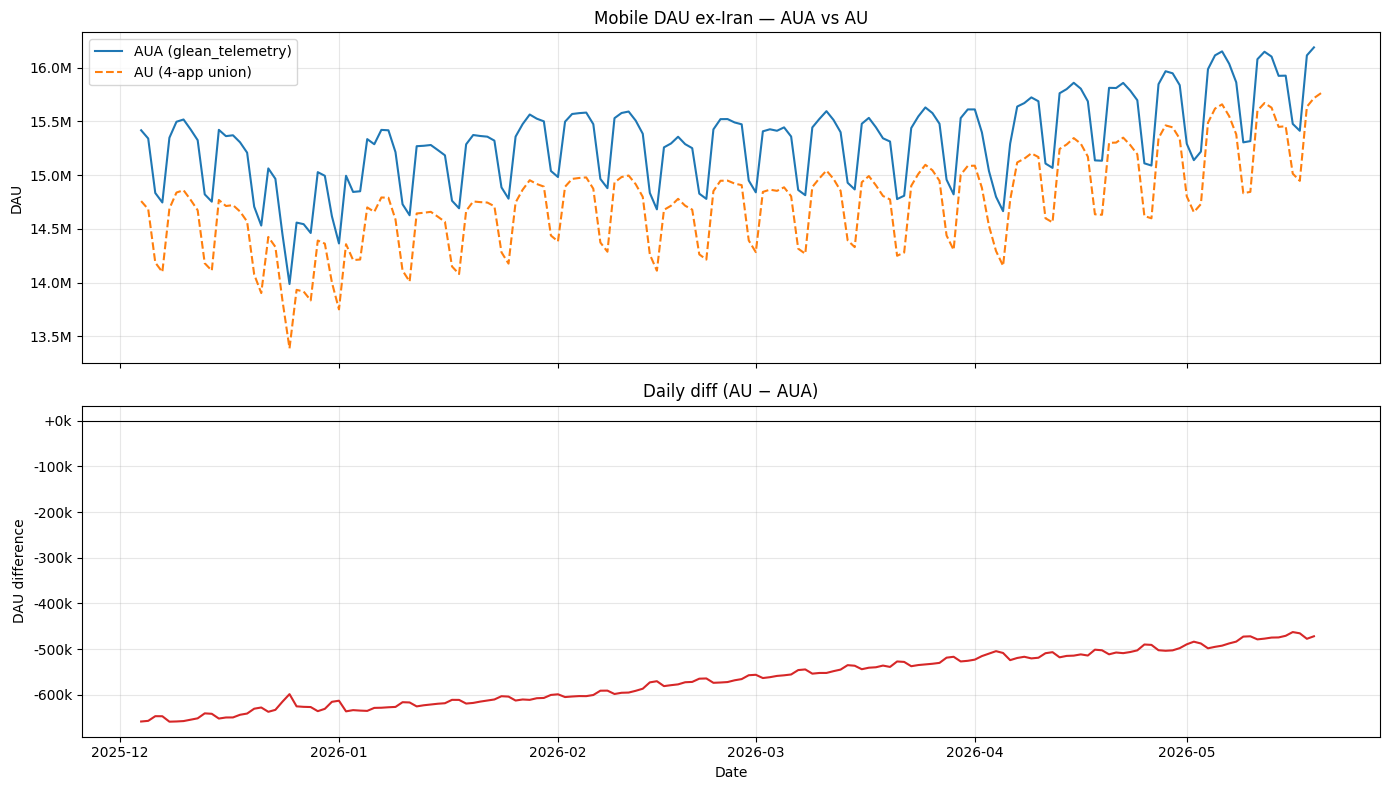

In [60]:
# aua-au-diff
# Daily diff. AUA should equal AU if the rollup is lossless.
cmp = aua_mobile.merge(au_mobile, on="date", how="outer", suffixes=("_aua", "_au")).sort_values("date")
cmp["diff_au_minus_aua"] = cmp["dau_au"] - cmp["dau_aua"]
cmp["pct_diff"] = 100.0 * cmp["diff_au_minus_aua"] / cmp["dau_aua"]

print("Date range:", cmp["date"].min().date(), "->", cmp["date"].max().date(), f"({len(cmp)} days)")
print()
print("=== Summary (AU − AUA) ===")
print(f"  mean abs diff:    {cmp['diff_au_minus_aua'].abs().mean():>12,.0f}")
print(f"  max  abs diff:    {cmp['diff_au_minus_aua'].abs().max():>12,.0f}")
print(f"  median diff:      {cmp['diff_au_minus_aua'].median():>12,.0f}")
print(f"  mean pct diff:    {cmp['pct_diff'].mean():>12.3f}%")
print(f"  exact matches:    {(cmp['diff_au_minus_aua']==0).sum():>12,d} / {len(cmp)}")

print()
print("=== Top 10 dates by abs diff ===")
print(cmp.reindex(cmp["diff_au_minus_aua"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

# Diff plot
fig, (ax_levels, ax_diff) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax_levels.plot(cmp["date"], cmp["dau_aua"], label="AUA (glean_telemetry)", color="tab:blue")
ax_levels.plot(cmp["date"], cmp["dau_au"], label="AU (4-app union)", color="tab:orange", linestyle="--")
ax_levels.set_title("Mobile DAU ex-Iran — AUA vs AU")
ax_levels.set_ylabel("DAU")
ax_levels.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.1f}M"))
ax_levels.grid(True, alpha=0.3)
ax_levels.legend()

ax_diff.plot(cmp["date"], cmp["diff_au_minus_aua"], color="tab:red")
ax_diff.axhline(0, color="black", linewidth=0.8)
ax_diff.set_title("Daily diff (AU − AUA)")
ax_diff.set_xlabel("Date")
ax_diff.set_ylabel("DAU difference")
ax_diff.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:+,.0f}k"))
ax_diff.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== Summary of MA28 diff (AU − AUA) ===
  observations:            140
  mean diff:          -566,754
  median diff:        -566,504
  mean abs diff:       566,754
  max  abs diff:       639,594


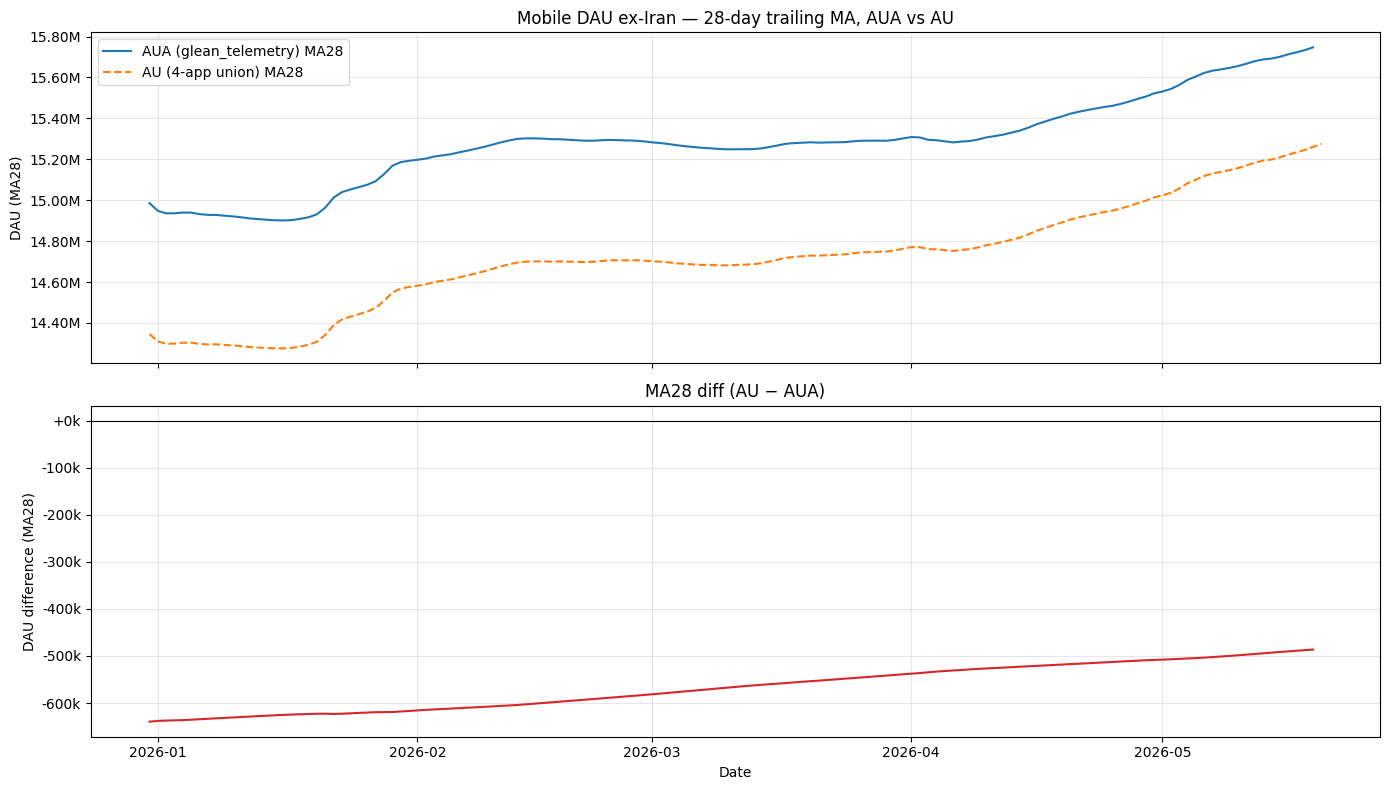

In [61]:
# aua-au-diff-ma28
# 28-day trailing MAs of AUA and AU, and the daily diff of the MAs.
# (First 27 rows are NaN and dropped by matplotlib.)
cmp_ma = cmp.set_index("date")[["dau_aua", "dau_au"]].rolling(28).mean()
cmp_ma["diff_au_minus_aua_ma28"] = cmp_ma["dau_au"] - cmp_ma["dau_aua"]

print("=== Summary of MA28 diff (AU − AUA) ===")
non_nan = cmp_ma["diff_au_minus_aua_ma28"].dropna()
print(f"  observations:   {len(non_nan):>12,d}")
print(f"  mean diff:      {non_nan.mean():>12,.0f}")
print(f"  median diff:    {non_nan.median():>12,.0f}")
print(f"  mean abs diff:  {non_nan.abs().mean():>12,.0f}")
print(f"  max  abs diff:  {non_nan.abs().max():>12,.0f}")

fig, (ax_levels, ax_diff) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax_levels.plot(cmp_ma.index, cmp_ma["dau_aua"], label="AUA (glean_telemetry) MA28", color="tab:blue")
ax_levels.plot(cmp_ma.index, cmp_ma["dau_au"], label="AU (4-app union) MA28", color="tab:orange", linestyle="--")
ax_levels.set_title("Mobile DAU ex-Iran — 28-day trailing MA, AUA vs AU")
ax_levels.set_ylabel("DAU (MA28)")
ax_levels.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.2f}M"))
ax_levels.grid(True, alpha=0.3)
ax_levels.legend()

ax_diff.plot(cmp_ma.index, cmp_ma["diff_au_minus_aua_ma28"], color="tab:red")
ax_diff.axhline(0, color="black", linewidth=0.8)
ax_diff.set_title("MA28 diff (AU − AUA)")
ax_diff.set_xlabel("Date")
ax_diff.set_ylabel("DAU difference (MA28)")
ax_diff.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:+,.0f}k"))
ax_diff.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
